In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix,f1_score, recall_score, precision_score
from sklearn.tree import plot_tree

from sklearn.model_selection import GridSearchCV

In [2]:
df=pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape

(150, 5)

In [5]:
X=df.drop(columns=['species'])
Y=df['species']

In [8]:
le=LabelEncoder()
y=le.fit_transform(Y)

/tmp/ipykernel_2600/536274095.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


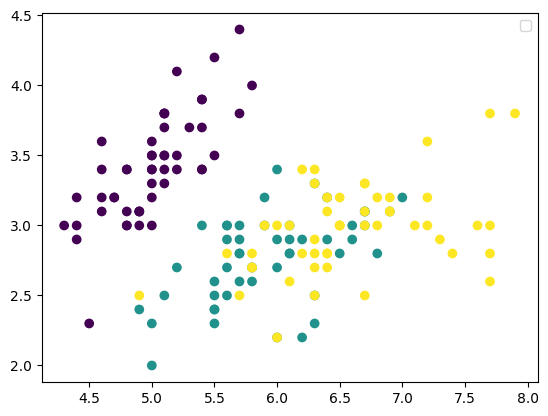

In [42]:
plt.scatter(df['sepal_length'], df['sepal_width'], c=y)
plt.legend()

In [11]:
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=41, test_size=0.2)

In [63]:
svc=SVC(kernel='linear')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)

In [64]:
accuracy_score(y_test,y_pred)

0.9666666666666667

In [40]:
X.iloc[:,:2]

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


##**SVM with Kernel (Linear)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


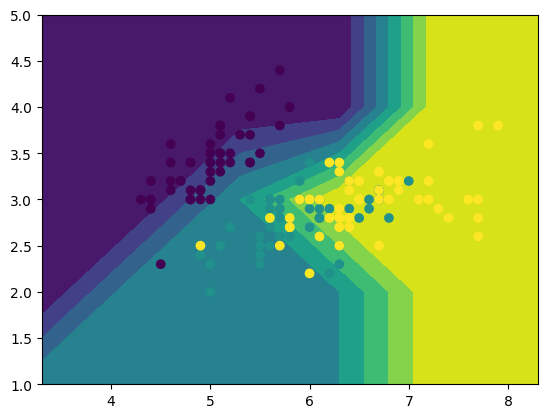

In [60]:
svc=SVC(kernel='linear')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
svc.fit(X.iloc[:,:2], y)

x_min,x_max = X.iloc[:,0].min()-1 , X.iloc[:,0].max()+1
y_min , y_max = X.iloc[:,1].min()-1 , X.iloc[:,1].max()+1

xx,yy = np.meshgrid(np.arange(x_min,x_max) , np.arange(y_min, y_max))

z=svc.predict(np.array([xx.ravel(),yy.ravel()]).T)
z=z.reshape(xx.shape)

plt.contourf(xx,yy,z)
plt.scatter(df['sepal_length'], df['sepal_width'], c=y)

##**SVM with Kernel(rbf)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


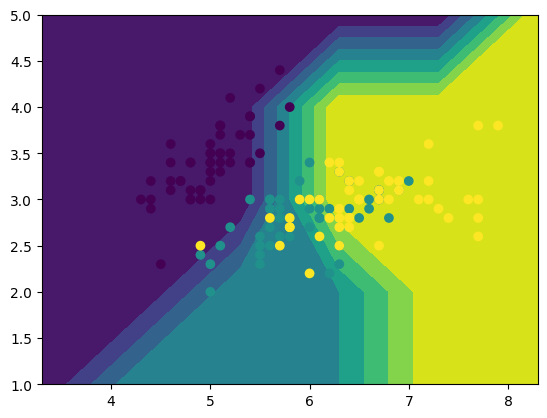

In [61]:
svc=SVC(kernel='rbf')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
svc.fit(X.iloc[:,:2], y)

x_min,x_max = X.iloc[:,0].min()-1 , X.iloc[:,0].max()+1
y_min , y_max = X.iloc[:,1].min()-1 , X.iloc[:,1].max()+1

xx,yy = np.meshgrid(np.arange(x_min,x_max) , np.arange(y_min, y_max))

z=svc.predict(np.array([xx.ravel(),yy.ravel()]).T)
z=z.reshape(xx.shape)

plt.contourf(xx,yy,z)
plt.scatter(df['sepal_length'], df['sepal_width'], c=y)

##**Evaluate the Model**

In [65]:
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred, average='weighted'))
print('confusion_matrix:\n',confusion_matrix(y_test,y_pred))
print('recall_score:',recall_score(y_test,y_pred, average='weighted'))
print('precision_score:',precision_score(y_test,y_pred, average='weighted'))

accuracy_score: 0.9666666666666667
f1_score: 0.9666666666666667
confusion_matrix:
 [[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]
recall_score: 0.9666666666666667
precision_score: 0.9696969696969696
